### What this notebook does

| Step | Description |
|---|---|
| Data Loading | Sanitation.xlsx — Sheet5 (genus-level counts) + Sheet0 (TPC, colony count) |
| Imputation | 4 sequencing dropouts + 7 singleton detections → replaced with day-wise group means |
| Unassigned removal | `g__Unassigned` column excluded |
| Non-genus removal | Columns containing `(` (phylum/class/order/family level annotations) excluded |
| Rare feature filter | Features with detection rate < 10% in both pre- and post-Day 9 samples excluded |
| CLR transformation | Per-sample transformation; no cross-sample fitting → no data leakage |
| IQR capping | Day-wise outlier capping applied in CLR-transformed space |
| TPC merging | TPC (log CFU/g) merged after CLR transformation is complete |
| 70:20:10 Split | Independent stratified splits for each of seeds 38–47 → saved as `splits.pkl` |

---

### ⚠️ What this notebook does NOT do

| Item | Rationale | Responsible file |
|---|---|---|
| Fold-change calculation | Must be computed from **train data only** after splitting to prevent leakage | `screening.ipynb` |
| ANOVA-based feature selection | Same rationale | `screening.ipynb` |
| VIP score calculation | Label-dependent PLS-DA — **train only** required | `screening.ipynb` |
| Class label assignment (Early/Intermediate/Late) | Optuna/K-means thresholds fit on **train data only** | `labeling.ipynb` |

**Pipeline order**: `preprocessing.ipynb` → `labeling.ipynb` → `screening.ipynb` → `classification.ipynb` → `regression.ipynb`

---

--- 

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import re 
import os
from sklearn.preprocessing import StandardScaler

import pickle
from IPython.display import display


# folder path
data_dir = "/home/admin-01/taeho/BRL_chicken"
sanitation_path = os.path.join(data_dir, 'Sanitation.xlsx')
output_dir = "/home/admin-01/taeho/BRL_chicken/revision/code"

PKL_DIR = os.path.join(output_dir, "data", "pkl")
os.makedirs(PKL_DIR, exist_ok=True)

## 1. Data Loading

- **Sheet0** (`균 수`): Description, TPC (log CFU/g), CC (log CFU/g)
- **Sheet5** (`Genus`): Description + genus taxa (`g__` prefix)
- Genus level only — Exclude Phylum/Class/Order/Family

In [2]:
# microbial (Sheet0): Description, TPC (log CFU/g), CC (log CFU/g)
data_microbial = pd.read_excel(sanitation_path, sheet_name=0, skiprows=2, usecols="B:D")

# taxonomic - Genus level만 (Sheet5)
data_genus_raw = pd.read_excel(sanitation_path, sheet_name=5, skiprows=2, usecols='B:WL')
data_genus_raw.columns = [data_genus_raw.columns[0]] + ['g__' + col for col in data_genus_raw.columns[1:]]

print(f"microbial shape : {data_microbial.shape}  | columns: {data_microbial.columns.tolist()}")
print(f"genus shape     : {data_genus_raw.shape}  | first 5 cols: {data_genus_raw.columns[:5].tolist()}")
print(f"총 샘플 수       : {len(data_genus_raw)}")

microbial shape : (270, 3)  | columns: ['Description', 'TPC (log CFU/g)', 'CC (log CFU/g)']
genus shape     : (270, 609)  | first 5 cols: ['Description', 'g__Leuconostoc', 'g__Corynebacterium', 'g__Lactococcus', 'g__Chryseobacterium']
총 샘플 수       : 270


## 2. Imputation

Samples with sequencing dropout or singleton detection were replaced with day-wise group means, followed by re-normalization to a sum of 100.

- **Sequencing dropouts (n=4)**: A5-22, A7-4, A7-16, A7-28
- **Singleton detection**: Samples in which total relative abundance = 100 and only a single feature was detected → that feature was set to 0 prior to imputation
- **Imputation reference**: Mean values of remaining samples from the same storage day

In [3]:
fail_samples = ["A5-22", "A7-4", "A7-16", "A7-28"]

def extract_day(description):
    m = re.match(r'A(\d+)-\d+', str(description))
    return int(m.group(1)) if m else np.nan

df = data_genus_raw.copy()
feature_cols = [col for col in df.columns if col != 'Description']
df['Day'] = df['Description'].apply(extract_day)

# 1. 시퀀싱 탈락 시료
fail_mask = df['Description'].isin(fail_samples)
actual_fail_samples = df.loc[fail_mask, 'Description'].tolist()

# 2. 단일 feature만 검출된 시료
only_100_mask = ((df[feature_cols] == 100).sum(axis=1) == 1) & \
                ((df[feature_cols] != 0).sum(axis=1) == 1)
only_100_samples = df.loc[only_100_mask, 'Description'].tolist()

# 3. 단일 검출 샘플의 100 값 → 0으로 초기화
for idx in df[only_100_mask].index:
    df.loc[idx, feature_cols] = 0

all_replaced_samples = actual_fail_samples + only_100_samples

# 4. Day별 평균(대체 대상 제외)으로 대체
all_replaced_mask = df['Description'].isin(all_replaced_samples)
for idx in df[all_replaced_mask].index:
    day = df.loc[idx, 'Day']
    day_mask = (df['Day'] == day) & (~df['Description'].isin(all_replaced_samples))
    day_df = df.loc[day_mask, feature_cols]
    if len(day_df) > 0:
        df.loc[idx, feature_cols] = day_df.mean().fillna(0).values
    else:
        df.loc[idx, feature_cols] = 0

# 5. 합계 100 재정규화
for idx in df.index:
    total = df.loc[idx, feature_cols].sum()
    if total > 0:
        df.loc[idx, feature_cols] = df.loc[idx, feature_cols] / total * 100

df = df.drop(columns=['Day'])
genus_imputed = df

print(f"시퀀싱 탈락 시료({len(actual_fail_samples)}개): {actual_fail_samples}")
print(f"단일 검출 시료({len(only_100_samples)}개): {only_100_samples}")
print(f"총 대체 샘플: {len(all_replaced_samples)}개")
print(f"genus_imputed shape: {genus_imputed.shape}")

sums = genus_imputed[feature_cols].sum(axis=1)
print(f"\n정규화 확인 — 합계 평균: {sums.mean():.2f}, 최소: {sums.min():.2f}, 최대: {sums.max():.2f}")

시퀀싱 탈락 시료(4개): ['A5-22', 'A7-4', 'A7-16', 'A7-28']
단일 검출 시료(7개): ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
총 대체 샘플: 11개
genus_imputed shape: (270, 609)

정규화 확인 — 합계 평균: 100.00, 최소: 100.00, 최대: 100.00


## 3. Unassigned Feature Removal

The `g__Unassigned` column was removed prior to CLR transformation.

- Removal was performed **before CLR** to prevent the unassigned taxon from contributing to the geometric mean calculation

In [4]:
unassigned_col = 'g__Unassigned'
before_shape = genus_imputed.shape

if unassigned_col in genus_imputed.columns:
    genus_no_unassigned = genus_imputed.drop(columns=[unassigned_col])
    print(f"'{unassigned_col}' 제거: {before_shape} → {genus_no_unassigned.shape}")
else:
    genus_no_unassigned = genus_imputed.copy()
    print(f"'{unassigned_col}' 컬럼 없음, 그대로 진행")

feature_cols = [col for col in genus_no_unassigned.columns if col != 'Description']
print(f"남은 feature 수: {len(feature_cols)}")

'g__Unassigned' 제거: (270, 609) → (270, 608)
남은 feature 수: 607


## 3-1. Non-genus Feature Removal

Features not resolved to genus level were removed: columns containing `(` in their name correspond to higher-level taxonomic annotations (domain, phylum, class, order, or family).
Removal was performed before CLR transformation to prevent contamination of the geometric mean.

In [5]:
non_genus = [
    col for col in genus_no_unassigned.columns
    if col != 'Description' and '(' in col
]
genus_no_unassigned = genus_no_unassigned.drop(columns=non_genus)

print(f"Non-genus features removed: {len(non_genus)}")
for f in non_genus:
    print(f"  {f}")
print(f"Remaining features: {len([c for c in genus_no_unassigned.columns if c != 'Description'])}")

Non-genus features removed: 114
  g__Atopobiaceae(f)
  g__Bacilli(c)
  g__Proteobacteria(p)
  g__Micavibrionales(o)
  g__Microbacteriaceae(f)
  g__Enterobacterales(o)
  g__Bacteria(d)
  g__Flavobacteriaceae(f)
  g__Micrococcaceae(f)
  g__Lactobacillales(o)
  g__Weeksellaceae(f)
  g__Gammaproteobacteria(c)
  g__Rhizobiaceae(f)
  g__Enterobacteriaceae(f)
  g__Erwiniaceae(f)
  g__Yersiniaceae(f)
  g__Lachnospiraceae(f)
  g__Comamonadaceae(f)
  g__Rhodospirillales(o)
  g__Rhodobacteraceae(f)
  g__Peptostreptococcales-Tissierellales(f)
  g__Caulobacteraceae(f)
  g__Staphylococcaceae(f)
  g__Planococcaceae(f)
  g__Carnobacteriaceae(f)
  g__Intrasporangiaceae(f)
  g__Caldilineaceae(f)
  g__Pseudomonadaceae(f)
  g__Dermacoccaceae(f)
  g__Promicromonosporaceae(f)
  g__Actinomycetaceae(f)
  g__Alphaproteobacteria(c)
  g__Xanthomonadaceae(f)
  g__Moraxellaceae(f)
  g__Flavobacteriales(o)
  g__Enterococcaceae(f)
  g__Burkholderiaceae(f)
  g__Sphingomonadaceae(f)
  g__Gimesiaceae(f)
  g__Oscillospi

## 4. Rare Feature Filtering

Features with a detection rate below 10% in **both** the early (Day < 9) and late (Day ≥ 9) storage periods were removed.

- Applied to raw relative abundance data (0–100%) prior to CLR transformation
- A feature was retained if detection rate reached ≥ 10% in **either** period; removal required sub-threshold detection in both

In [6]:
df_tmp = genus_no_unassigned.copy()
df_tmp['Day'] = df_tmp['Description'].apply(extract_day)
feature_cols = [col for col in df_tmp.columns if col not in ['Description', 'Day']]

selected_features = []
removed_features = []

for feat in feature_cols:
    before_mask = df_tmp['Day'] < 9
    after_mask = df_tmp['Day'] >= 9

    before_ratio = (df_tmp.loc[before_mask, feat] > 0).sum() / before_mask.sum() \
        if before_mask.sum() > 0 else 0
    after_ratio = (df_tmp.loc[after_mask, feat] > 0).sum() / after_mask.sum() \
        if after_mask.sum() > 0 else 0

    if before_ratio < 0.1 and after_ratio < 0.1:
        removed_features.append(feat)
    else:
        selected_features.append(feat)

genus_rare_filtered = df_tmp[['Description'] + selected_features].copy()
print(f"제거: {len(removed_features)}개 / 유지: {len(selected_features)}개")
print(f"shape: {genus_no_unassigned.shape} → {genus_rare_filtered.shape}")
if removed_features:
    print(f"제거된 feature 예시 (최대 5개): {removed_features[:5]}")

제거: 383개 / 유지: 110개
shape: (270, 494) → (270, 111)
제거된 feature 예시 (최대 5개): ['g__Thermomicrobiales_JG30-KF-CM45', 'g__Roseimarinus', 'g__Sericytochromatia', 'g__Paludibacter', 'g__Litorimonas']


## 5. Pseudocount & CLR Transformation

- **Pseudocount**: A value of `1e-6` was added exclusively to zero entries
- **CLR transformation**: `CLR(x) = log(x) − mean(log(x))` — computed per sample with no cross-sample fitting
- Post-transformation CLR sum ≈ 0 verified for each sample

---

> **CLR transformation prior to train/test splitting does not introduce data leakage**
>
> The `mean(log(x))` term in the CLR formula is the mean of features **within the same sample**
> and does not reference values from any other sample (no cross-sample statistics).
> Because each sample is transformed independently, no information from the training set
> can propagate to the test or validation sets.
>
> In contrast, ANOVA, PLS-DA (VIP), and K-means clustering operate across multiple samples simultaneously
> and must therefore be fit exclusively on training data after splitting. → See `screening.ipynb`, `labeling.ipynb`

---

> **Rare feature filtering is performed before CLR transformation**
>
> The geometric mean `G(x) = exp(mean(log(x)))` in CLR is computed from **all features** within a sample.
> Assigning a pseudocount (`1e-6`) to rare features — most of whose values are zero —
> introduces artificially small values that distort the geometric mean
> and thereby **affect the CLR values of all remaining features**.
>
> Gloor et al. (2017) explicitly state that "G(x) cannot be computed for sparse data
> without deleting, replacing, or imputing zero values," and accordingly,
> **removing rare features prior to pseudocount application is the standard practice
> for stabilizing the geometric mean**
> (Gloor et al., 2017; Nearing et al., 2020; Erawijantari et al., 2023).
>
> The features retained after filtering still constitute a valid subcomposition,
> and CLR applied to this subcomposition is mathematically justified.

In [7]:
feature_cols = [col for col in genus_rare_filtered.columns if col != 'Description']

df_clr = genus_rare_filtered.copy()

# 0값 → pseudocount
df_clr[feature_cols] = df_clr[feature_cols].replace(0, 1e-6)

# CLR 변환
X = df_clr[feature_cols].values.astype(np.float64)
log_X = np.log(X)
gm = log_X.mean(axis=1, keepdims=True)
clr_X = log_X - gm
df_clr[feature_cols] = clr_X

# 검증
row_sums = df_clr[feature_cols].sum(axis=1)
print(f"CLR row sum 범위: {row_sums.min():.2e} ~ {row_sums.max():.2e}")
print(f"CLR 값 범위: {clr_X.min():.3f} ~ {clr_X.max():.3f}")
print(f"shape: {df_clr.shape}")

genus_clr = df_clr

CLR row sum 범위: -4.07e-12 ~ 2.03e-13
CLR 값 범위: -10.763 ~ 17.523
shape: (270, 111)


## 6. IQR Outlier Capping

Outliers were capped within the CLR-transformed space on a per-storage-day basis.

- Values below `Q1 − 1.5×IQR` → replaced with Q1
- Values above `Q3 + 1.5×IQR` → replaced with Q3
- **Applied separately by storage day**: distributions differ substantially between early (Day 0) and late (Day 18) timepoints; pooling across days would result in excessive capping

In [8]:
feature_cols = [col for col in genus_clr.columns if col != 'Description']

df_iqr = genus_clr.copy()
df_iqr['Day'] = df_iqr['Description'].apply(extract_day)

total_replaced = 0

for feat in feature_cols:
    for day, group in df_iqr.groupby('Day'):
        vals = group[feat].dropna()
        if len(vals) < 4:
            continue
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        idxs = group.index
        before = df_iqr.loc[idxs, feat].copy()
        df_iqr.loc[idxs, feat] = df_iqr.loc[idxs, feat].clip(lower=lower, upper=upper)
        total_replaced += (before != df_iqr.loc[idxs, feat]).sum()

df_iqr = df_iqr.drop(columns=['Day'])
genus_final = df_iqr

print(f"IQR 캡핑 완료: 총 {total_replaced}개 값 대체됨")
print(f"genus_final shape: {genus_final.shape}")
print(f"CLR 값 범위 (IQR 후): {genus_final[feature_cols].values.min():.3f} ~ {genus_final[feature_cols].values.max():.3f}")

IQR 캡핑 완료: 총 2681개 값 대체됨
genus_final shape: (270, 111)
CLR 값 범위 (IQR 후): -9.569 ~ 17.257


## 7. TPC Merge

TPC (log CFU/g) and CC (log CFU/g) were merged into the CLR-preprocessed dataset.

- Merging was performed prior to splitting so that TPC is available in each of the train, test, and validation subsets
- TPC serves as the basis for class label assignment (threshold fitting) and as the regression target

In [9]:
feature_cols = [col for col in genus_final.columns if col != 'Description']

genus_with_tpc = pd.merge(
    genus_final,
    data_microbial[['Description', 'TPC (log CFU/g)', 'CC (log CFU/g)']],
    on='Description',
    how='left'
)

print(f"shape: {genus_with_tpc.shape}")
print(f"TPC 결측: {genus_with_tpc['TPC (log CFU/g)'].isna().sum()}개")
print(genus_with_tpc[['Description', 'TPC (log CFU/g)']].head())


shape: (270, 113)
TPC 결측: 0개
  Description  TPC (log CFU/g)
0        A0-1         3.681241
1        A0-2         3.922395
2        A0-3         4.137584
3        A0-4         3.792392
4        A0-5         3.462398


## 8. Train / Test / Validation Split (70 : 20 : 10)

Samples were partitioned in two steps using stratified splitting across 10 random seeds (38–47).

| Step | Subset | n | Proportion (overall) |
|---|---|---|---|
| Step 1 | Train + Test | 243 | 90% |
| Step 1 | Validation | 27 | 10% |
| Step 2 | Train | 189 | 70% |
| Step 2 | Test | 54 | 20% |

- **Step 1** (`test_size = 0.10`): validation set (n = 27) held out prior to any model training
- **Step 2** (`test_size = 20/90 ≈ 0.222`): remaining 243 samples split into train (n = 189) and test (n = 54)
- **Random seeds**: 38–47 (10 seeds total); performance reported as mean ± SD across seeds

In [10]:
from sklearn.model_selection import train_test_split
seeds = [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
splits = {}

data_for_split = genus_with_tpc.copy()

for seed in seeds:
    traintest_idx, val_idx = train_test_split(
        data_for_split.index, 
        test_size=0.10,
        random_state=seed
    )
    train_idx, test_idx = train_test_split(
        traintest_idx,
        test_size=20/90,
        random_state=seed
    )
    splits[seed] = {
        'train': data_for_split.loc[train_idx].reset_index(drop=True),
        'test':  data_for_split.loc[test_idx].reset_index(drop=True),
        'val':   data_for_split.loc[val_idx].reset_index(drop=True)
    }

for seed in seeds[:2]:
    tr = splits[seed]['train']
    te = splits[seed]['test']
    va = splits[seed]['val']
    print(f"seed={seed} | train: {len(tr)} / test: {len(te)} / val: {len(va)}")

print(f"\n총 {len(seeds)}개 seed 분리 완료: {seeds}")


seed=38 | train: 189 / test: 54 / val: 27
seed=39 | train: 189 / test: 54 / val: 27

총 10개 seed 분리 완료: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]


## 9. Save

- `genus_preprocessed.pkl`: CLR-preprocessed dataset for all 270 samples (prior to splitting)
- `splits.pkl`: Train / test / validation indices for each of the 10 random seeds
  - Shared across all downstream notebooks (labeling, screening, classification, regression)

In [11]:
# 전체 전처리 데이터 저장
preprocessed_path = os.path.join(PKL_DIR, 'genus_preprocessed.pkl')
with open(preprocessed_path, 'wb') as f:
    pickle.dump({
        'data': genus_with_tpc,
        'feature_cols': feature_cols,
        'description_col': 'Description',
        'tpc_col': 'TPC (log CFU/g)',
        'cc_col': 'CC (log CFU/g)'
    }, f)

splits_path = os.path.join(PKL_DIR, 'splits.pkl')
with open(splits_path, 'wb') as f:
    pickle.dump({
        'splits': splits,
        'seeds': seeds,
        'feature_cols': feature_cols,
        'tpc_col': 'TPC (log CFU/g)',
        'cc_col': 'CC (log CFU/g)'
    }, f)

print(f"저장 완료 → {PKL_DIR}")
print(f"  genus_preprocessed.pkl  ({genus_with_tpc.shape})")
print(f"  splits.pkl  (seeds: {seeds})")

저장 완료 → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl
  genus_preprocessed.pkl  ((270, 113))
  splits.pkl  (seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47])


## Before and After CLR Transformation

ANOVA significant features (seed-42 train, q<0.05): 100개


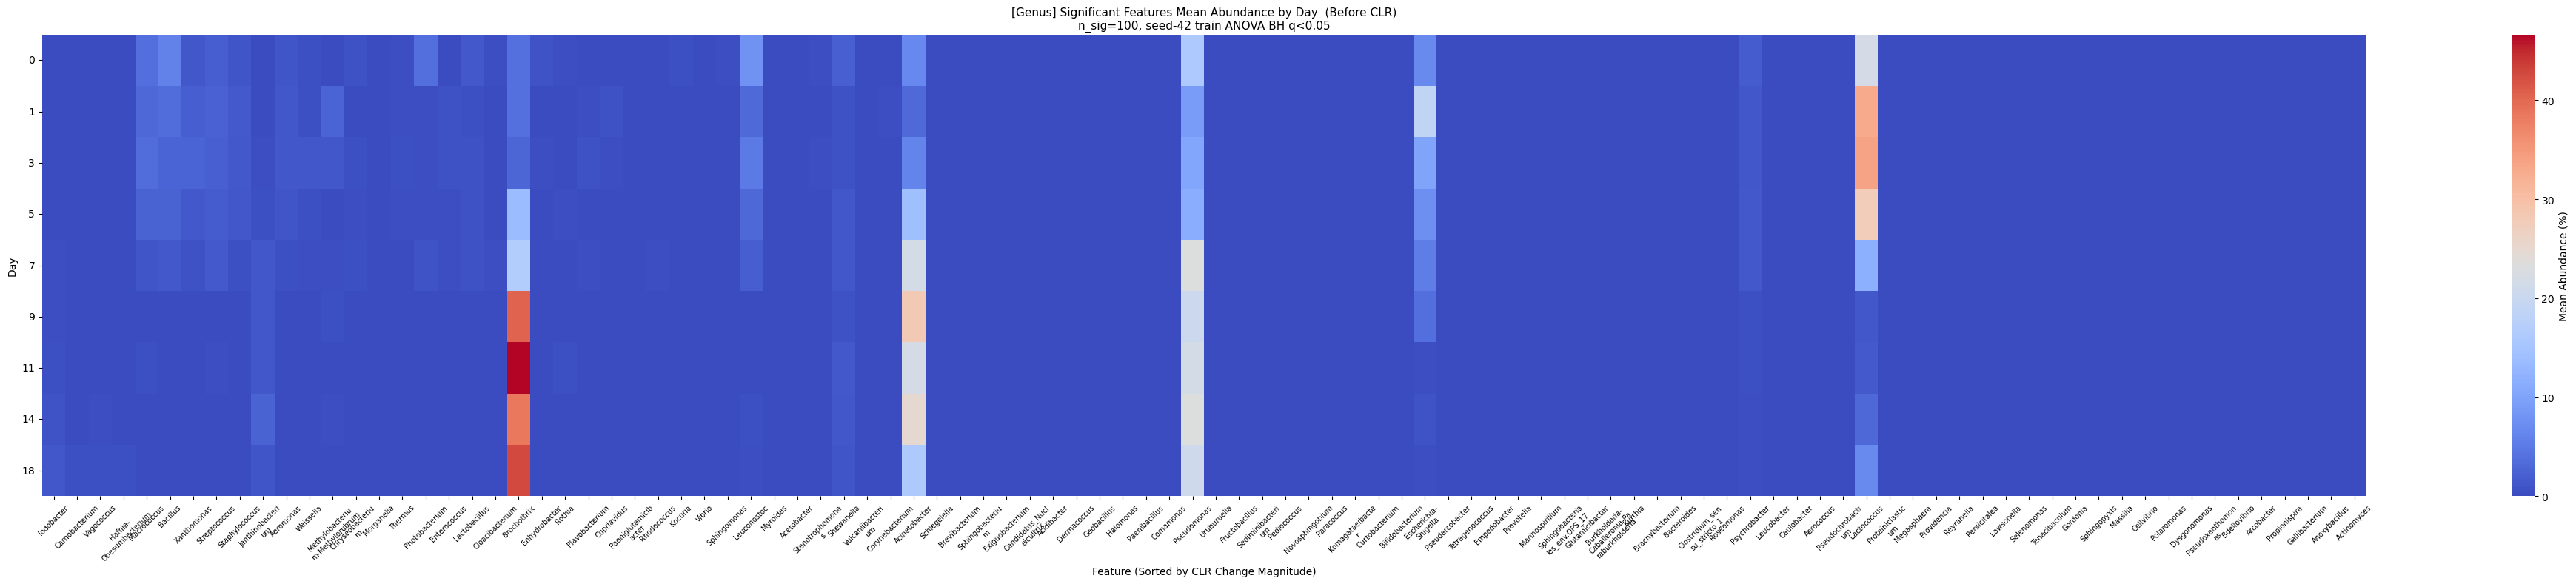

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_preprocessing/fig_clr_before.png


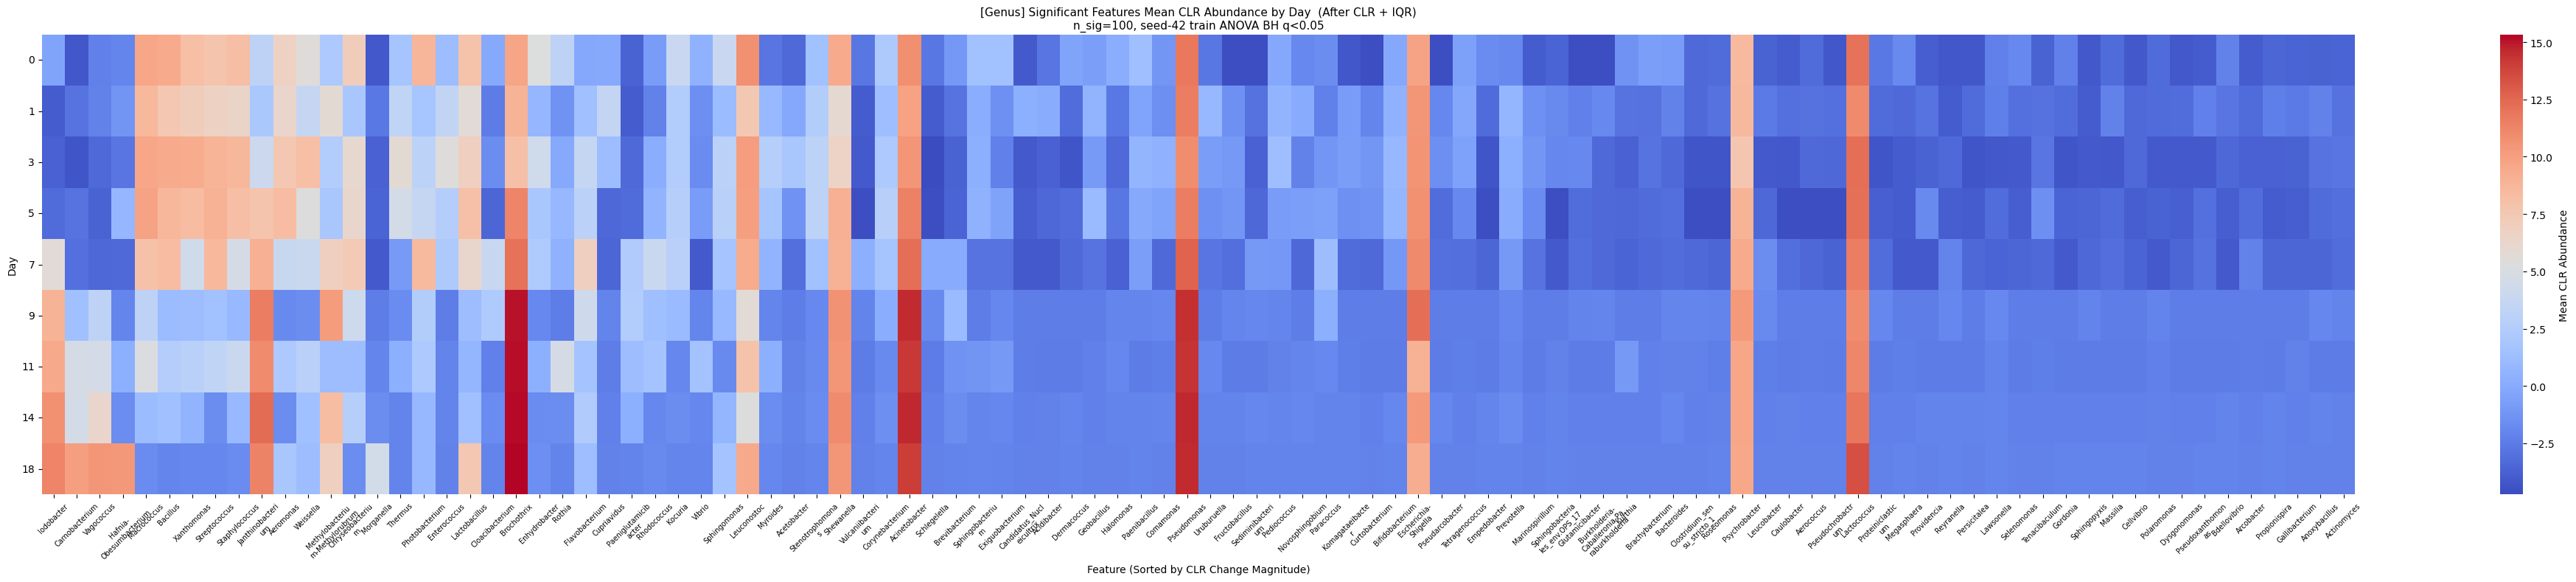

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_preprocessing/fig_clr_after.png

CLR 전 색상 범위: 0.000 ~ 46.636
CLR 후 색상 범위: -4.736 ~ 15.331


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests

FIGURE_DIR = os.path.join(output_dir, "figures_preprocessing")
os.makedirs(FIGURE_DIR, exist_ok=True)

LABEL_SEED = 42

# ── seed-42 train Description ─────────────────────────────────────
train_desc = set(splits[LABEL_SEED]['train']['Description'])

# ── ANOVA: seed-42 train only, BH q<0.05 ─────────────────────────
feat_cols = [c for c in genus_with_tpc.columns if c.startswith('g__')]

clr_train = genus_with_tpc[genus_with_tpc['Description'].isin(train_desc)].copy()
clr_train['Day'] = clr_train['Description'].apply(extract_day)

p_values, feats_valid = [], []
for feat in feat_cols:
    groups = [g[feat].dropna().values for _, g in clr_train.groupby('Day')]
    valid  = [g for g in groups if len(g) > 1]
    if len(valid) >= 2:
        _, p = f_oneway(*valid)
        p_values.append(float(p) if not np.isnan(p) else 1.0)
        feats_valid.append(feat)

_, q_values, _, _ = multipletests(p_values, method='fdr_bh')
sig_features = [f for f, q in zip(feats_valid, q_values) if q < 0.05]
print(f"ANOVA significant features (seed-{LABEL_SEED} train, q<0.05): {len(sig_features)}개")

# ── Day별 평균 ────────────────────────────────────────────────────
# CLR 변환 후 (전체 270 기준 시각화)
clr_plot = genus_with_tpc.copy()
clr_plot['Day'] = clr_plot['Description'].apply(extract_day)
clr_day_mean = clr_plot.groupby('Day')[sig_features].mean()

# CLR 변환 전 (genus_rare_filtered: 희귀 필터 이후, CLR 이전)
raw_plot = genus_rare_filtered.copy()
raw_plot['Day'] = raw_plot['Description'].apply(extract_day)
sig_in_raw = [f for f in sig_features if f in raw_plot.columns]
raw_day_mean = raw_plot.groupby('Day')[sig_in_raw].mean()

# ── Feature 정렬 (CLR 변화 크기 내림차순) ────────────────────────
feature_changes = (clr_day_mean.max() - clr_day_mean.min()).abs()
sorted_features  = feature_changes.sort_values(ascending=False).index.tolist()
sorted_in_raw    = [f for f in sorted_features if f in raw_day_mean.columns]

def clean_name(name):
    base = name.replace('g__', '')
    if '(' in base:
        base = base.split('(')[0].strip()
    return '\n'.join(textwrap.wrap(base, width=15))

sorted_short = [clean_name(f) for f in sorted_features]

fig_w = max(40, 0.22 * len(sorted_features))
fig_h = max(8,  0.5  * len(clr_day_mean))

# ── A) CLR 변환 전 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(raw_day_mean[sorted_in_raw], cmap='coolwarm', ax=ax,
            cbar_kws={'label': 'Mean Abundance (%)'},
            xticklabels=[clean_name(f) for f in sorted_in_raw])
ax.set_title(
    f'[Genus] Significant Features Mean Abundance by Day  (Before CLR)\n'
    f'n_sig={len(sig_features)}, seed-{LABEL_SEED} train ANOVA BH q<0.05',
    fontsize=11)
ax.set_xlabel('Feature (Sorted by CLR Change Magnitude)', fontsize=10)
ax.set_ylabel('Day', fontsize=10)
ax.tick_params(axis='x', labelsize=7,  rotation=45)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
path_before = os.path.join(FIGURE_DIR, 'fig_clr_before.png')
plt.savefig(path_before, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path_before}")

# ── B) CLR 변환 후 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(clr_day_mean[sorted_features], cmap='coolwarm', ax=ax,
            cbar_kws={'label': 'Mean CLR Abundance'},
            xticklabels=sorted_short)
ax.set_title(
    f'[Genus] Significant Features Mean CLR Abundance by Day  (After CLR + IQR)\n'
    f'n_sig={len(sig_features)}, seed-{LABEL_SEED} train ANOVA BH q<0.05',
    fontsize=11)
ax.set_xlabel('Feature (Sorted by CLR Change Magnitude)', fontsize=10)
ax.set_ylabel('Day', fontsize=10)
ax.tick_params(axis='x', labelsize=7,  rotation=45)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
path_after = os.path.join(FIGURE_DIR, 'fig_clr_after.png')
plt.savefig(path_after, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path_after}")

print(f"\nCLR 전 색상 범위: {raw_day_mean[sorted_in_raw].min().min():.3f} ~ {raw_day_mean[sorted_in_raw].max().max():.3f}")
print(f"CLR 후 색상 범위: {clr_day_mean[sorted_features].min().min():.3f} ~ {clr_day_mean[sorted_features].max().max():.3f}")